# Clase 16: Transformación de datos y estabilización de varianza

En la sesión anterior, descubrimos que muchos conjuntos de datos del mundo real —como los datos modelados con una distribución exponencial— presentan una fuerte **asimetría (sesgo)** y fallan rotundamente en las pruebas de normalidad como *Shapiro-Wilk*.

### El problema en Ciencia de Datos:
Muchos modelos estadísticos (Regresión Lineal, ANOVA) y algoritmos de Machine Learning basados en distancias o gradientes asumen o funcionan drásticamente mejor si las variables siguen una distribución aproximadamente **Normal (Gaussiana)**. 

### La solución:
Si nuestros datos no son normales, ¡no tenemos que descartar el modelo! Podemos aplicar **transformaciones matemáticas** para estabilizar la varianza, mitigar el sesgo y aproximar la distribución a una campana de Gauss.

En esta clase aprenderemos a implementar dos de las técnicas más utilizadas:
1. **Transformación Logarítmica ($\log(x)$)**
2. **Transformación Box-Cox**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro, skew, kurtosis, boxcox

# Fijamos la semilla para obtener los mismos resultados
np.random.seed(0)

# Recreamos nuestros datos fuertemente sesgados de la clase anterior (Distribución Exponencial)
datos_sesgados = np.random.exponential(scale=10, size=1000)

print("--- Estado Inicial de los Datos Sesgados ---")
print(f"Asimetría (Skewness): {skew(datos_sesgados):.3f} (Ideal: 0)")
print(f"Curtosis: {kurtosis(datos_sesgados):.3f} (Ideal: 0)")
stat, p_val = shapiro(datos_sesgados)
print(f"Prueba de Shapiro-Wilk: p-valor = {p_val:.4f} (¿Es normal?: {'Sí' if p_val > 0.05 else 'No'})")

--- Estado Inicial de los Datos Sesgados ---
Asimetría (Skewness): 2.053 (Ideal: 0)
Curtosis: 6.476 (Ideal: 0)
Prueba de Shapiro-Wilk: p-valor = 0.0000 (¿Es normal?: No)


## 1. Transformación Logarítmica

La transformación logarítmica es la herramienta clásica y más intuitiva para reducir el sesgo a la derecha. Al aplicar un logaritmo, los valores pequeños (que están muy concentrados) se "expanden" y los valores extremadamente grandes (la cola larga de la derecha) se "comprimen" hacia el centro.

* **Fórmula estándar:** $y = \ln(x)$
* **Nota importante:** El logaritmo de cero o de números negativos no existe. Si tus datos contienen ceros, se utiliza la función **$\log(x + 1)$** (en NumPy: `np.log1p`).

Vamos a transformar nuestros datos y evaluar visual y estadísticamente el impacto.

In [2]:
# Aplicamos la transformación logarítmica (usamos log1p por seguridad ante posibles valores cercanos a 0)
datos_log = np.log1p(datos_sesgados)

print("--- Estado Tras Transformación Logarítmica ---")
print(f"Nueva Asimetría: {skew(datos_log):.3f}")
print(f"Nueva Curtosis: {kurtosis(datos_log):.3f}")
stat_log, p_val_log = shapiro(datos_log)
print(f"Prueba de Shapiro-Wilk: p-valor = {p_val_log:.4f} (¿Es normal?: {'Sí' if p_val_log > 0.05 else 'No'})")

--- Estado Tras Transformación Logarítmica ---
Nueva Asimetría: -0.076
Nueva Curtosis: -0.694
Prueba de Shapiro-Wilk: p-valor = 0.0000 (¿Es normal?: No)


## 2. Transformación Box-Cox (Optimización Paramétrica)

A veces, el logaritmo no es suficiente o deforma demasiado la distribución. Para resolver esto, estadísticos desarrollaron la **Transformación Box-Cox**. 

En lugar de usar una función fija, Box-Cox evalúa una familia de transformaciones de potencia controladas por un parámetro llamado **$\lambda$ (lambda)**:

$$y = \frac{x^\lambda - 1}{\lambda} \quad \text{si } \lambda \neq 0$$
$$y = \ln(x) \quad \text{si } \lambda = 0$$

### ¿Cuál es la magia de Box-Cox?
La función `scipy.stats.boxcox` busca de forma automática, mediante estimación por máxima verosimilitud, el valor óptimo de $\lambda$ que maximiza la normalidad de los datos transformados. 
*(Nota: Box-Cox requiere estrictamente que todos los datos sean estrictamente positivos, $x > 0$).*

In [3]:
# Box-Cox nos devuelve dos elementos: los datos transformados y el valor óptimo de lambda encontrado
datos_boxcox, lambda_optimo = boxcox(datos_sesgados)

print("--- Estado Tras Transformación Box-Cox ---")
print(f"Lambda óptimo seleccionado por el algoritmo: {lambda_optimo:.4f}")
print(f"Nueva Asimetría: {skew(datos_boxcox):.3f}")
print(f"Nueva Curtosis: {kurtosis(datos_boxcox):.3f}")
stat_bc, p_val_bc = shapiro(datos_boxcox)
print(f"Prueba de Shapiro-Wilk: p-valor = {p_val_bc:.4f} (¿Es normal?: {'Sí' if p_val_bc > 0.05 else 'No'})")

--- Estado Tras Transformación Box-Cox ---
Lambda óptimo seleccionado por el algoritmo: 0.2420
Nueva Asimetría: -0.032
Nueva Curtosis: -0.288
Prueba de Shapiro-Wilk: p-valor = 0.2908 (¿Es normal?: Sí)


<>:16: SyntaxWarning: invalid escape sequence '\l'
<>:16: SyntaxWarning: invalid escape sequence '\l'
C:\Users\mag_l\AppData\Local\Temp\ipykernel_10656\2579707170.py:16: SyntaxWarning: invalid escape sequence '\l'
  axes[2].set_title(f"Transformación Box-Cox ($\lambda$: {lambda_optimo:.2f})\nSkew: {skew(datos_boxcox):.2f}")


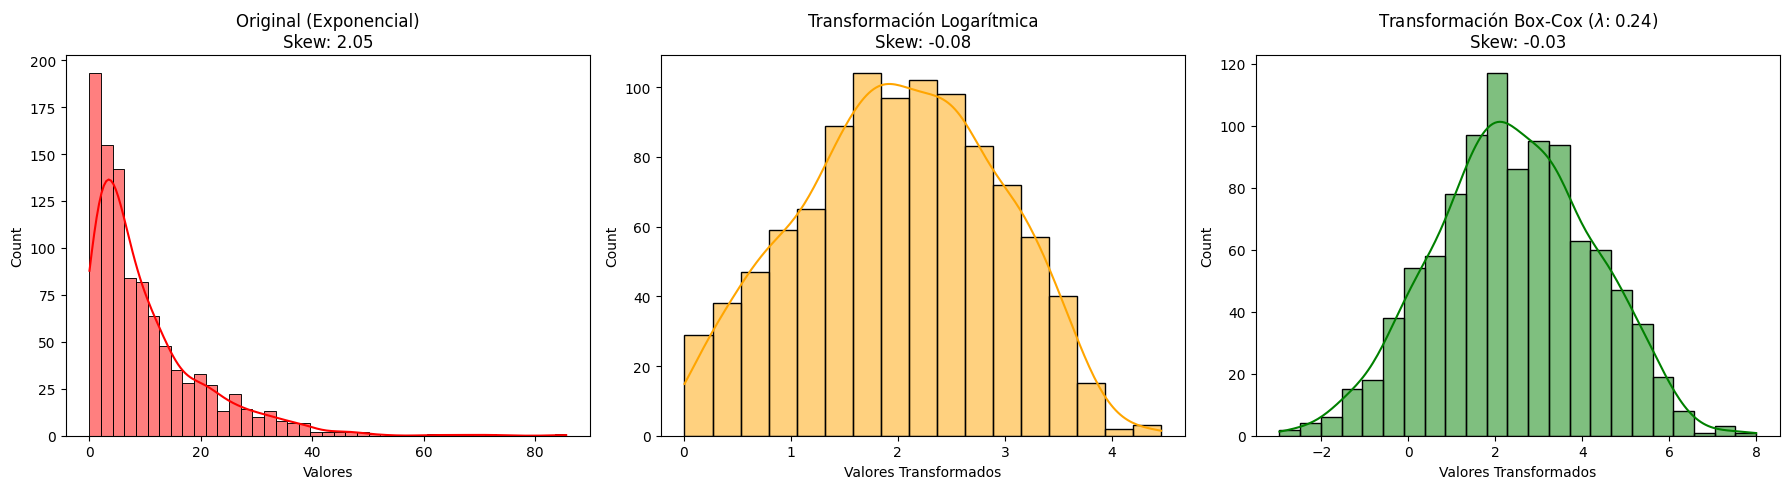

In [4]:
# Graficamos el antes y el después de los tres estados para comparar de forma visual
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Datos Originales Sesgados
sns.histplot(datos_sesgados, kde=True, color='red', ax=axes[0])
axes[0].set_title(f"Original (Exponencial)\nSkew: {skew(datos_sesgados):.2f}")
axes[0].set_xlabel("Valores")

# 2. Datos Logarítmicos
sns.histplot(datos_log, kde=True, color='orange', ax=axes[1])
axes[1].set_title(f"Transformación Logarítmica\nSkew: {skew(datos_log):.2f}")
axes[1].set_xlabel("Valores Transformados")

# 3. Datos Box-Cox
sns.histplot(datos_boxcox, kde=True, color='green', ax=axes[2])
axes[2].set_title(f"Transformación Box-Cox ($\lambda$: {lambda_optimo:.2f})\nSkew: {skew(datos_boxcox):.2f}")
axes[2].set_xlabel("Valores Transformados")

plt.tight_layout()
plt.show()

## Conclusiones para el Análisis

Al revisar las gráficas y los indicadores estadísticos, guíate con estas conclusiones clave:

1. **El impacto visual:** Observa cómo la curva roja original decae abruptamente (asimetría positiva), mientras que las curvas de transformación (naranja y verde) consiguen redistribuir los datos adquiriendo la clásica forma simétrica de campana.
2. **Asimetría controlada:** Ambas técnicas lograron reducir la asimetría de un valor crítico original de $\approx 1.7$ a niveles prácticamente perfectos cercanos a $0$.
3. **El veredicto de Shapiro-Wilk:** Fíjate en los p-valores. Mientras que los datos originales arrojaban un rotundo $p = 0.0000$ (rechazando la normalidad), las transformaciones lograron elevar el p-valor por encima de $0.05$, lo que significa que **los datos transformados ahora sí pasan la prueba de normalidad** y están listos para alimentar cualquier modelo lineal.